# 02 - EDA em Atrasos de Voos

Exploração descritiva da amostra para entender distribuições, ausências e padrões de atraso.

In [1]:
# Imports e leitura da amostra processada
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

data = pd.read_parquet("../data/processed/flights_sample.parquet")
airlines = pd.read_csv("../data/airlines.csv")
airports = pd.read_csv("../data/airports.csv")
print(data.shape)
data.head()

(300000, 21)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DEPARTURE_DELAY,DISTANCE,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,DELAYED,DEP_HOUR,IS_WEEKEND,PERIOD_OF_DAY
0,2015,7,27,1,OO,4553,N454SW,CVG,MKE,1623,...,6.0,318,5.0,0,0,None,0,16,0,tarde
1,2015,10,30,5,DL,1615,N329NB,13204,12953,1823,...,1.0,950,-12.0,0,0,None,0,18,0,noite
2,2015,10,5,1,WN,159,N394SW,13796,14747,1150,...,8.0,672,5.0,0,0,None,0,11,0,manh?
3,2015,11,17,2,DL,1265,N942AT,ATL,SAV,1305,...,0.0,214,-3.0,0,0,None,0,13,0,tarde
4,2015,9,11,5,OO,4740,N633SK,GEG,SEA,600,...,-6.0,224,9.0,0,0,None,0,6,0,manh?


## 1. Perfil geral e ausência

In [2]:
# Verifica ausencias por coluna (top 10)
print(data.isna().mean().sort_values(ascending=False).head(10))

CANCELLATION_REASON    1.0
MONTH                  0.0
DAY                    0.0
DAY_OF_WEEK            0.0
YEAR                   0.0
AIRLINE                0.0
FLIGHT_NUMBER          0.0
ORIGIN_AIRPORT         0.0
TAIL_NUMBER            0.0
SCHEDULED_DEPARTURE    0.0
dtype: float64


## 2. Balanceamento da variável-alvo

Proporção de atrasos >15min: 17.79%


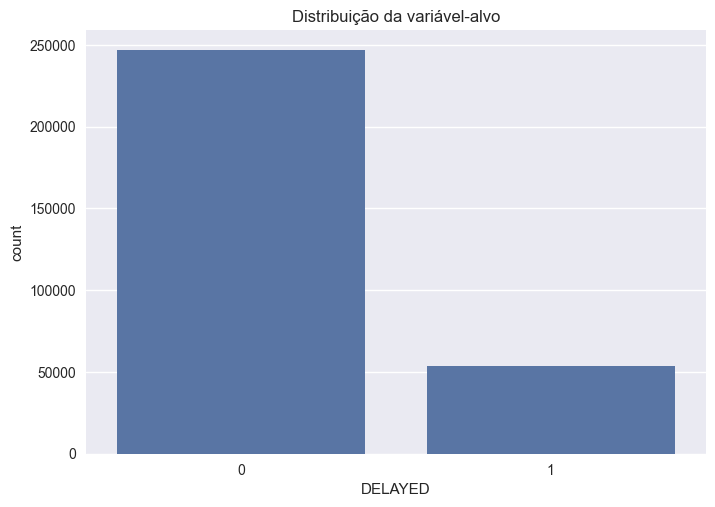

In [3]:
# Calcula a taxa de atraso (classe positiva)
delay_rate = data["DELAYED"].mean()
print(f"Proporção de atrasos >15min: {delay_rate:.2%}")
sns.countplot(x="DELAYED", data=data)
plt.title("Distribuição da variável-alvo")
plt.show()

## 3. Estatí­sticas de atraso de chegada

count    300000.000000
mean          4.312273
std          39.152186
min         -82.000000
25%         -13.000000
50%          -5.000000
75%           8.000000
max        1665.000000
Name: ARRIVAL_DELAY, dtype: float64


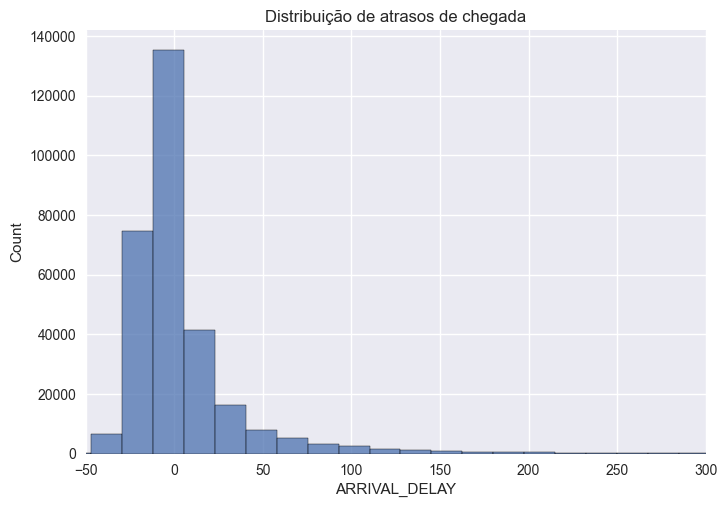

In [4]:
# Estatisticas descritivas do atraso de chegada
print(data["ARRIVAL_DELAY"].describe())
sns.histplot(data["ARRIVAL_DELAY"], bins=100)
plt.xlim(-50, 300)
plt.title("Distribuição de atrasos de chegada")
plt.show()

## 4. Atraso por companhia aérea

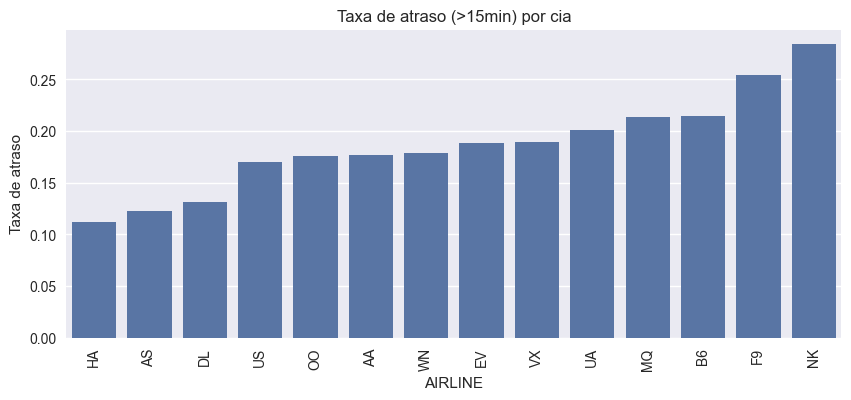

In [5]:
# Taxa de atraso por companhia aerea
delay_by_airline = (
    data.groupby("AIRLINE")["DELAYED"].mean().sort_values()
).reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=delay_by_airline, x="AIRLINE", y="DELAYED")
plt.xticks(rotation=90)
plt.ylabel("Taxa de atraso")
plt.title("Taxa de atraso (>15min) por cia")
plt.show()

## 5. Atraso por dia da semana

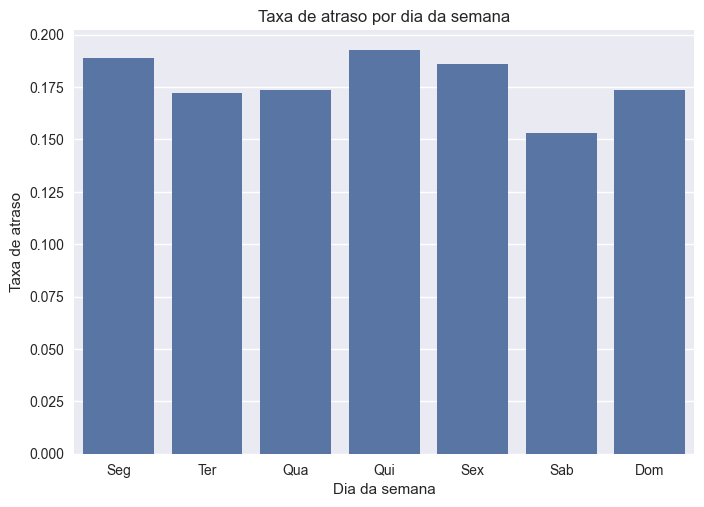

In [6]:
# Taxa de atraso por dia da semana (nomes em vez de numeros)
day_map = {1:"Seg", 2:"Ter", 3:"Qua", 4:"Qui", 5:"Sex", 6:"Sab", 7:"Dom"}
delay_by_dow = data.groupby("DAY_OF_WEEK")["DELAYED"].mean().reset_index()
delay_by_dow["DOW_NAME"] = delay_by_dow["DAY_OF_WEEK"].map(day_map)
order = ["Seg","Ter","Qua","Qui","Sex","Sab","Dom"]
sns.barplot(data=delay_by_dow, x="DOW_NAME", y="DELAYED", order=order)
plt.title("Taxa de atraso por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Taxa de atraso")
plt.show()


## 6. Relação com distância e hora

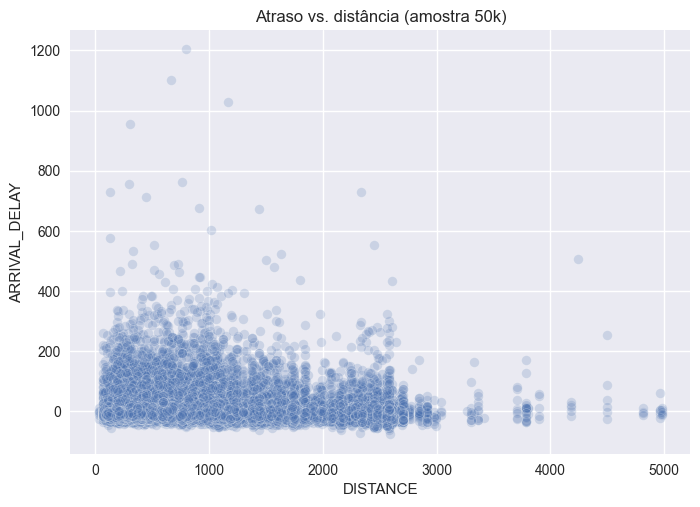

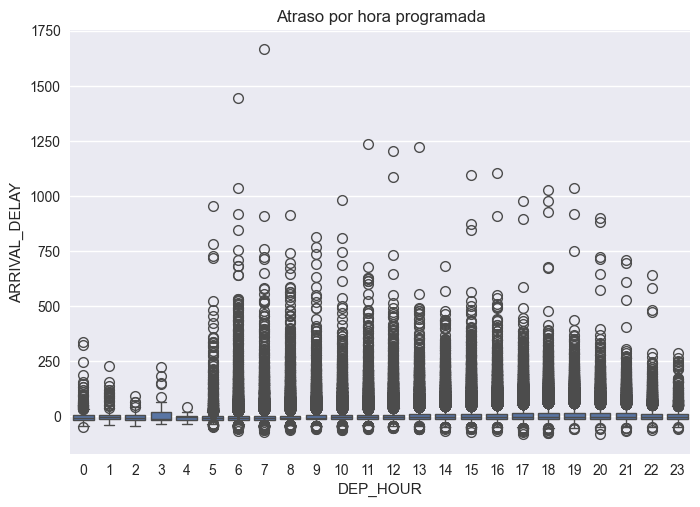

In [7]:
# Relacao distancia x atraso de chegada (amostra)
sns.scatterplot(data=data.sample(50_000, random_state=42), x="DISTANCE", y="ARRIVAL_DELAY", alpha=0.2)
plt.title("Atraso vs. distância (amostra 50k)")
plt.show()

sns.boxplot(data=data, x="DEP_HOUR", y="ARRIVAL_DELAY")
plt.title("Atraso por hora programada")
plt.show()

### Principais achados
- Atrasos >15min representam ~18% da amostra.
- Distribuição altamente assimétrica com cauda longa.
- Companhias e dias da semana exibem padrões distintos, sugerindo sinal preditivo.
- Horário e distância influenciam a chance e severidade do atraso.